  **Soham Kharabe**

  **C C2 23**

  **ML Lab - 7**

  **29/09/2026**

**Navie Baies Classifier** :-

    * Is an Supervised Machine Learning Algorithm.

    * Makes Strong Simplifying Assumptions

    * Assumes All Features are Imdependent of Each Other

    * Only Used For Classification

    * It Has 3 Types:
         1) Gaussian Naive Bayes -Continuous / Numerical data & Normally Distributed
         2) Multinomial Naive Bayes - Discrete / Count data
            eg. Frequency of Occurences
         3) Bernoulli Naive Bayes - Binary / Boolean data

$$P(A\vert{}B) = \frac{P(B\vert{}A) \cdot P(A)}{P(B)}$$

where,
      
P(B): Probability of Target

P(A): Probability of Predictor

P(B|A): Probability of B given By A








In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv("/content/bank_Notes.csv")

In [ ]:
df.head()

,variance,skewness,curtosis,entropy,Target
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.tail()

,variance,skewness,curtosis,entropy,Target
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [ ]:
df.shape

(1372, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   Target    1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df.dtypes

,0
variance,float64
skewness,float64
curtosis,float64
entropy,float64
Target,int64


In [ ]:
df.describe()

,variance,skewness,curtosis,entropy,Target
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
Target,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


Bar *Plot*

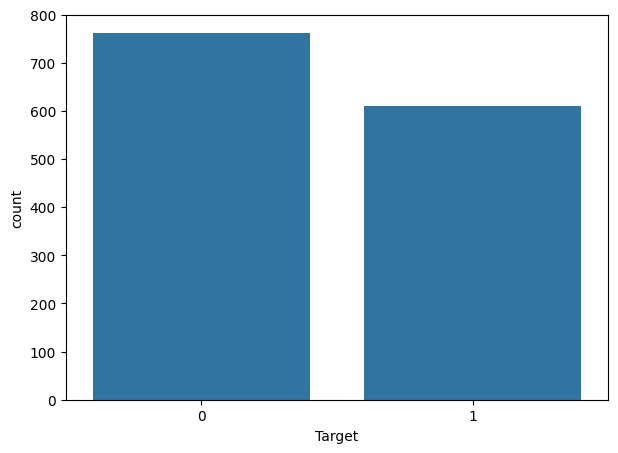

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Target")
plt.show()

Pie Chart

In [ ]:
class_counts = df["Class"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(class_counts,label=class_counts.index,autopct="%1,1f%%",startangle=90)
plt.title('Distribution of Rasin Classes')
plt.show()


KeyError: 'Class'

Numerical Features

In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns
print("Numerical Features")
print(numerical_features.tolist())

Numerical Features
['variance', 'skewness', 'curtosis', 'entropy', 'Target']


Histogram

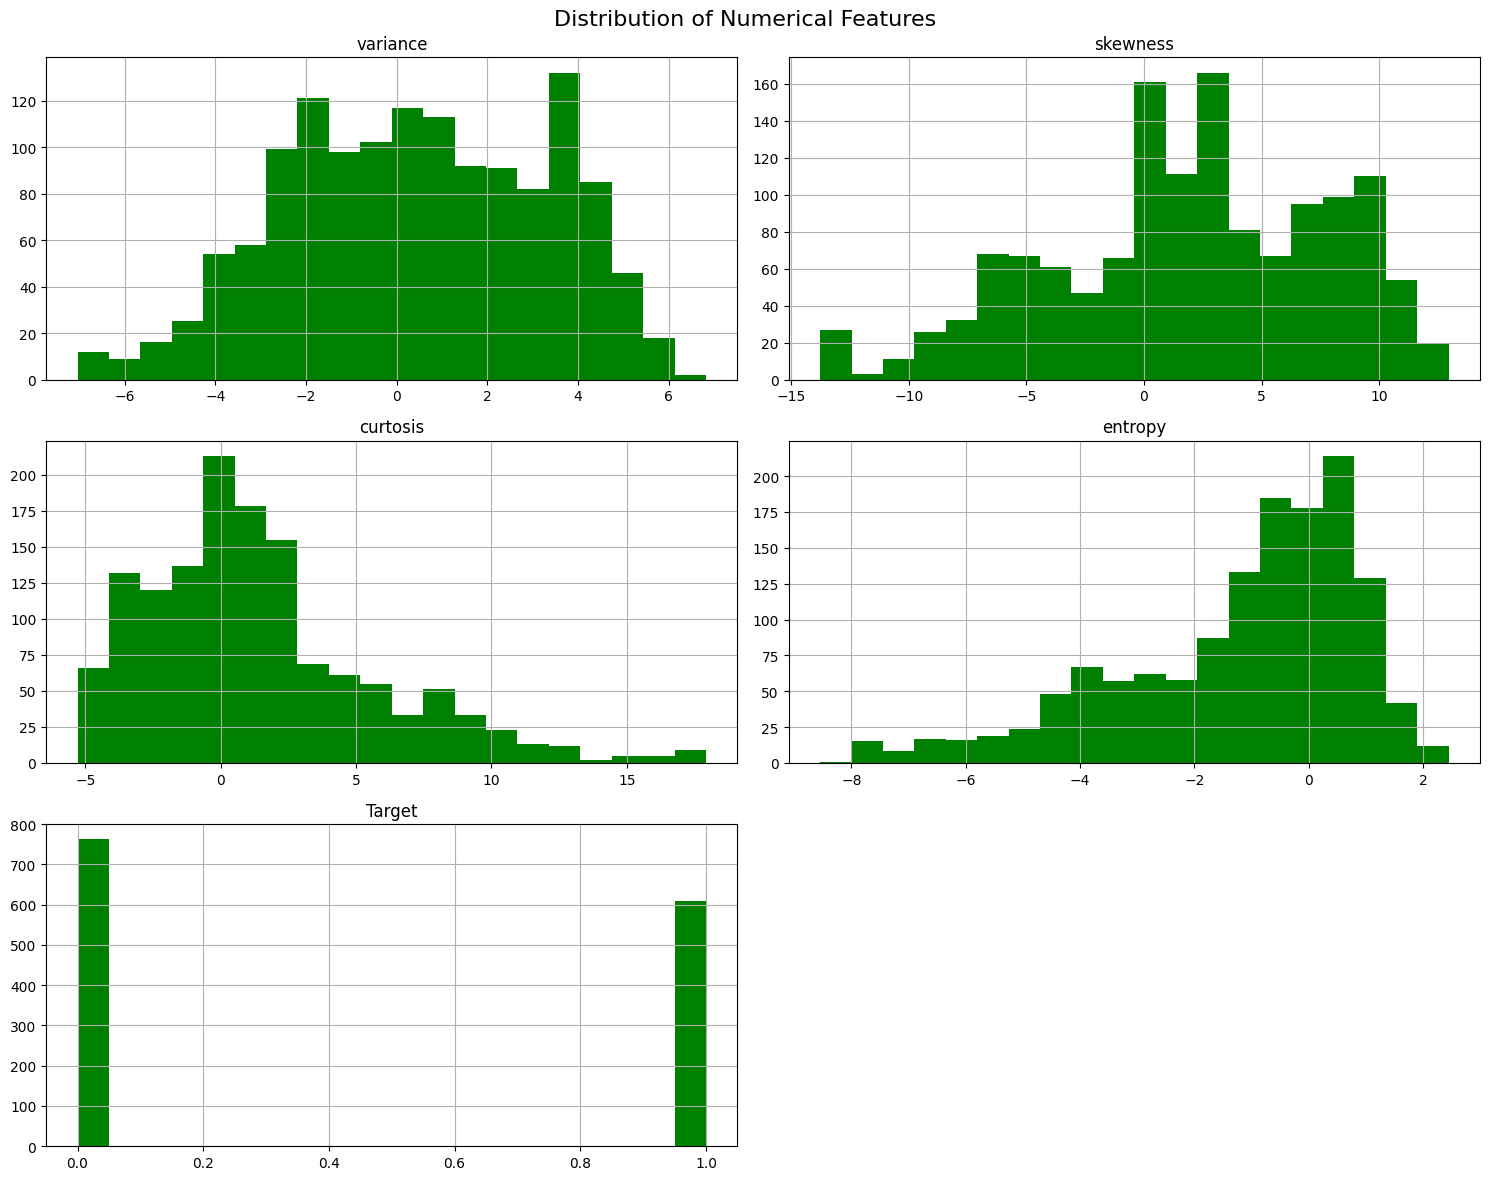

In [ ]:
df[numerical_features].hist(figsize=(15,12),bins=20,color='Green')
plt.suptitle("Distribution of Numerical Features",fontsize=16)
plt.tight_layout()
plt.show()

BoxPlot

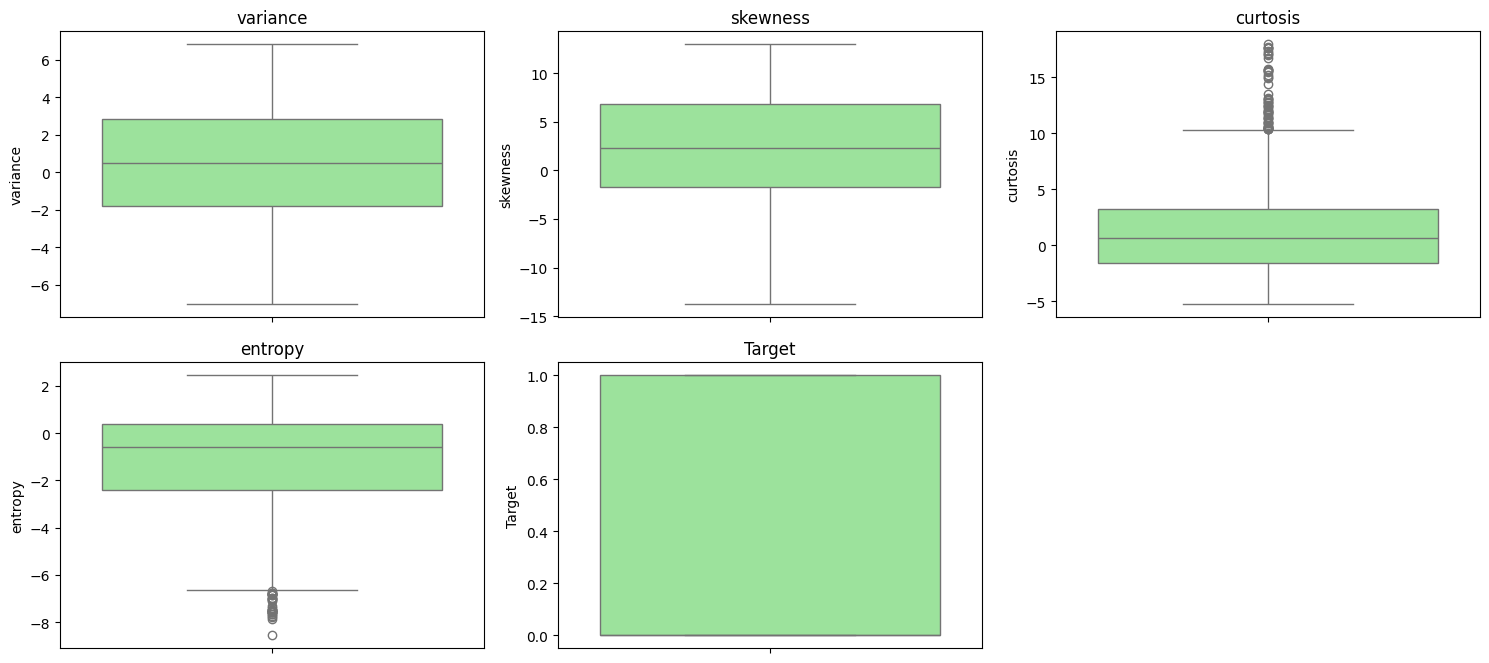

In [ ]:
plt.figure(figsize=(15,10))
for i, column in enumerate(numerical_features,1):
  plt.subplot(3, 3, i)
  sns.boxplot(y=df[column],color='lightgreen')
  plt.title(column)
plt.tight_layout()
plt.show()